# 02 · Cleaning & Normalization
Builds before/after windows, applies VADER sentiment, and pace-adjusts stats across eras.

Outputs: `data/processed/windows.csv` and `data/processed/normalized.csv`

In [9]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')


In [10]:
# Step 1: Score sentiment on lyric snippets
from src.sentiment import score_lyrics
df_sentiment = score_lyrics('../data/raw/mentions.csv')
print(df_sentiment[['player','artist','lyric','vader_compound']].head(10))


Saved sentiment scores to D:\Codes\hip-hoop\notebooks\..\data\processed\mentions_with_sentiment.csv

Sentiment summary:
count    110.000
mean       0.139
std        0.296
min       -0.743
25%        0.000
50%        0.077
75%        0.361
max        0.649
Name: vader_compound, dtype: float64

Mean by mention_type:
mention_type
compliment    0.146
diss         -0.035
neutral       0.156
Name: vader_compound, dtype: float64
             player            artist  \
0      LeBron James             Drake   
1       Kobe Bryant         Lil Wayne   
2  Shaquille O'Neal  Notorious B.I.G.   
3     Allen Iverson             Jay-Z   
4      Kevin Durant    Kendrick Lamar   
5     Patrick Ewing  Notorious B.I.G.   
6    Michael Jordan             Jay-Z   
7       Gary Payton             Jay-Z   
8      Vince Carter          Ludacris   
9        Tim Duncan            Common   

                                               lyric  vader_compound  
0  That's why they call me Young Money LeBron Jam..

Task was destroyed but it is pending!
task: <Task pending name='Task-115' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-116' coro=<Kernel.shell_main() running at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\weakref.py:452: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return self.data.get(ref(key),default)
Task was destroyed but it is pending!
task: <Task pending name='Task-116' coro=<Kernel.shell_main() running at C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task

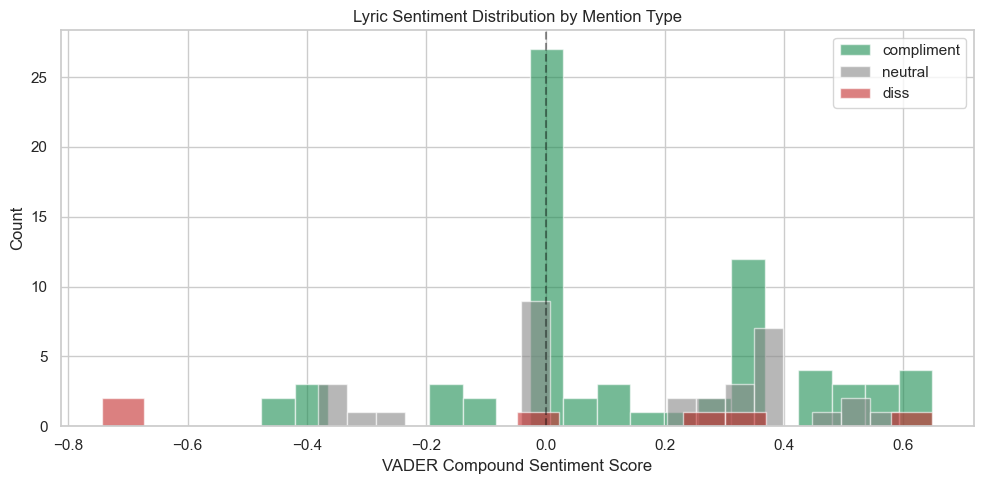

Note: sentiment scores don't always match manual labels — that's the point.


In [11]:
# Visualize sentiment distribution by mention type
fig, ax = plt.subplots(figsize=(10, 5))
for t, color in [('compliment','#1A8C50'), ('neutral','#888'), ('diss','#C42B2B')]:
    sub = df_sentiment[df_sentiment['mention_type'] == t]['vader_compound']
    ax.hist(sub, bins=20, alpha=0.6, label=t, color=color)
ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('VADER Compound Sentiment Score')
ax.set_ylabel('Count')
ax.set_title('Lyric Sentiment Distribution by Mention Type')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/sentiment_distribution.png', dpi=150)
plt.show()
print("Note: sentiment scores don't always match manual labels — that's the point.")


In [12]:
# Step 2: Build before/after windows from game logs
from src.build_windows import build_windows
df_windows = build_windows()
print(f"Windows shape: {df_windows.shape}")
print(df_windows[['player','mention_type','before_PTS_mean','after_30g_PTS_mean']].head(10))


  ⚠ Insufficient data for Patrick Ewing around 1994-09-13
  ⚠ Insufficient data for Michael Jordan around 2003-11-14
  ⚠ Insufficient data for Gary Payton around 1996-06-25
  ⚠ Insufficient data for Vince Carter around 2000-09-26
  ⚠ Insufficient data for Tim Duncan around 2005-05-24
  ⚠ Insufficient data for James Harden around 2016-09-16
  ⚠ Insufficient data for Giannis Antetokounmpo around 2018-05-25
  ✗ No game log found for: Luka Doncic
  ⚠ Insufficient data for Dwight Howard around 2010-09-17
  ⚠ Insufficient data for Derrick Rose around 2013-05-18
  ⚠ Insufficient data for Baron Davis around 2006-03-28
  ✗ No game log found for: Penny Hardaway
  ⚠ Insufficient data for Stephon Marbury around 2002-05-14
  ⚠ Insufficient data for Tracy McGrady around 2008-06-10
  ⚠ Insufficient data for Yao Ming around 2005-08-30
  ⚠ Insufficient data for Jason Kidd around 2001-09-11
  ⚠ Insufficient data for Steve Nash around 2008-06-10
  ✗ No game log found for: Amare Stoudemire
  ⚠ Insufficien

In [13]:
# Check for missing data
missing = df_windows.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print(f"\nComplete rows: {df_windows.dropna(subset=['after_30g_PTS_mean']).shape[0]}")


Missing values per column:
after_1g_PTS_std    51
after_1g_AST_std    51
after_1g_REB_std    51
dtype: int64

Complete rows: 51


In [14]:
# Step 3: Pace-adjust and compute deltas
from src.normalize import normalize
df_norm = normalize()
print("\nDelta columns created:")
delta_cols = [c for c in df_norm.columns if c.startswith('delta_')]
print(delta_cols)


Normalized data saved to D:\Codes\hip-hoop\notebooks\..\data\processed\normalized.csv
Shape: (51, 91)

Delta columns created:
['delta_after_1g_PTS', 'delta_after_1g_PTS_adj', 'delta_after_1g_AST', 'delta_after_1g_AST_adj', 'delta_after_1g_REB', 'delta_after_1g_REB_adj', 'delta_after_10g_PTS', 'delta_after_10g_PTS_adj', 'delta_after_10g_AST', 'delta_after_10g_AST_adj', 'delta_after_10g_REB', 'delta_after_10g_REB_adj', 'delta_after_30g_PTS', 'delta_after_30g_PTS_adj', 'delta_after_30g_AST', 'delta_after_30g_AST_adj', 'delta_after_30g_REB', 'delta_after_30g_REB_adj', 'delta_after_season_PTS', 'delta_after_season_PTS_adj', 'delta_after_season_AST', 'delta_after_season_AST_adj', 'delta_after_season_REB', 'delta_after_season_REB_adj']


In [15]:
# Preview key delta stats
print(df_norm[['player','mention_type','delta_after_30g_PTS_adj',
               'delta_after_30g_AST_adj','delta_after_30g_REB_adj',
               'composite_delta_30g']].dropna().head(15))


               player mention_type  delta_after_30g_PTS_adj  \
0        LeBron James   compliment                    -2.73   
1         Kobe Bryant   compliment                     2.94   
2    Shaquille O'Neal   compliment                    -2.31   
3       Allen Iverson   compliment                     1.94   
4        Kevin Durant      neutral                     0.44   
5         Dwyane Wade   compliment                    -2.22   
6          Chris Paul   compliment                    -1.20   
7       Kevin Garnett   compliment                    -0.18   
8       Stephen Curry   compliment                    -3.55   
9        Kyrie Irving      neutral                     2.24   
10          Ja Morant   compliment                     5.53   
11  Russell Westbrook         diss                     9.10   
12    Carmelo Anthony   compliment                     1.55   
13        Paul Pierce      neutral                     0.28   
14      Dirk Nowitzki   compliment                    -

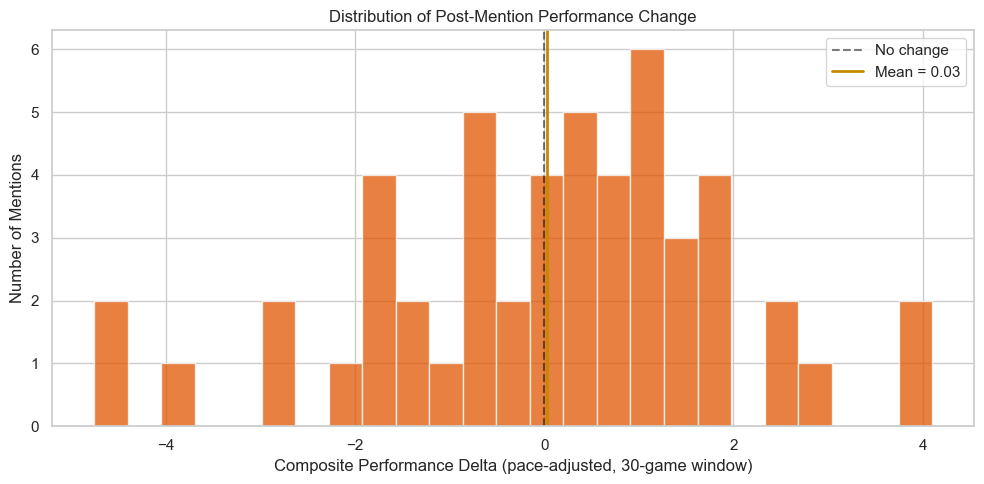

In [16]:
# Distribution of composite deltas
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_norm.dropna(subset=['composite_delta_30g'])
ax.hist(df_plot['composite_delta_30g'], bins=25, color='#E05500', alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='No change')
ax.axvline(df_plot['composite_delta_30g'].mean(), color='#C48A00', linestyle='-',
           linewidth=2, label=f"Mean = {df_plot['composite_delta_30g'].mean():.2f}")
ax.set_xlabel('Composite Performance Delta (pace-adjusted, 30-game window)')
ax.set_ylabel('Number of Mentions')
ax.set_title('Distribution of Post-Mention Performance Change')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/delta_distribution.png', dpi=150)
plt.show()
